# Mini-Projeto Avaliativo (M1S07) — Análise Exploratória da base Varejo

**Análise de Dados com Python — Turma T5 (SENAI / LAB365)**

Este notebook é o **projeto resolvido**, do jeito mais simples possível. Você não precisa escrever nada: basta **executar as células, de cima para baixo**, e ler o texto antes e depois de cada uma. No fim, você terá feito todas as etapas que o enunciado pede:

| Etapa do enunciado | Onde está neste notebook |
|---|---|
| Carregar a base e mostrar registros, colunas e tipos | Passos 1 e 2 |
| Verificar problemas (nulos, duplicatas, categorias vazias) | Passo 3 |
| Limpeza mínima (nulos, categorias, duplicatas, tipos) | Passos 4 a 7 |
| Regra do número da compra (`CO_ID`) | Passo 8 |
| Estatísticas do número de filhos (`CL_FHL`) | Passo 9 |
| Dois ou mais agrupamentos com `groupby()` | Passos 10 a 12 |
| Arquivo `df_limpo.csv` | Passo 13 |
| Conclusões (3 a 6 tópicos) | Passo 14 |

### Como executar

- **VS Code:** abra a pasta `T5_miniprojeto/Aluno` (menu **File → Open Folder**), abra este notebook, escolha o kernel **Python 3** no canto superior direito (**Select Kernel**) e clique em **Run All** (ou execute célula por célula com **Shift+Enter**).
- **Google Colab:** abra o notebook no Colab e execute a célula do Passo 0.2: ela pede para você enviar o arquivo `varejo.csv` (que está na pasta `dataset/` do repositório).

A base tem **830 mil linhas**; algumas células levam alguns segundos. Enquanto uma célula roda, aparece um relógio (ou um quadrado girando) ao lado dela. **Toda célula funciona sozinha**: cada uma lê a base de novo e repete as limpezas anteriores (com o comentário `# Passo X`), para você nunca depender de ter executado a célula de cima.

## Passo 0 — Preparando o ambiente

### 0.1 — Instalando as bibliotecas

### 📖 Antes do código

O comando `%pip install` instala bibliotecas no Python que está executando este notebook. O projeto usa o **Pandas** (tabelas) e o **Matplotlib** (gráficos). Se as duas já estiverem instaladas, a célula só avisa `Requirement already satisfied` e segue. O `csv` e o `datetime` já vêm com o Python e não precisam de instalação.

In [1]:
%pip install pandas matplotlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


**Deu certo?** As últimas linhas mostram `Successfully installed ...` ou `Requirement already satisfied ...`. Se instalou algo agora, clique em **Restart** na barra do notebook antes de continuar.

### 0.2 — Só no Google Colab: enviando a base

### 📖 Antes do código

No **VS Code**, o arquivo `dataset/varejo.csv` já está na pasta, e esta célula só mostra uma mensagem. No **Colab**, a sessão começa vazia: a função `files.upload()` abre uma janela para você escolher o `varejo.csv` no seu computador, e o `os.replace()` move o arquivo enviado para dentro da pasta `dataset/`, que é onde o resto do notebook procura. O `try/except ImportError` decide sozinho em qual dos dois ambientes você está.

In [2]:
import os

try:
    from google.colab import files
    enviados = files.upload()
    os.makedirs("dataset", exist_ok=True)
    for nome in enviados:
        os.replace(nome, f"dataset/{nome}")
    print("Arquivo enviado para a pasta dataset/.")
except ImportError:
    print("Rodando localmente (VS Code) — o arquivo já está em dataset/, nesta pasta.")

Rodando localmente (VS Code) — o arquivo já está em dataset/, nesta pasta.


## Passo 1 — Lendo a base com `csv.DictReader` (Sprint 1)

### 📖 Antes do código

O `csv.DictReader` é a leitura **nativa** do Python que você viu na Semana 04. Ele lê o arquivo **uma linha por vez** e entrega cada linha como um **dicionário**: a chave é o nome da coluna (`"DATA"`, `"PR_CAT"`...) e o valor é o texto daquela linha.

| Trecho | O que faz |
|---|---|
| `open(CAMINHO, encoding="utf-8", newline="")` | abre o arquivo para leitura; `newline=""` é a forma recomendada de abrir CSV |
| `csv.DictReader(arquivo, delimiter=";")` | cria o leitor; nesta base as colunas são separadas por **ponto e vírgula** |
| `leitor.fieldnames` | a lista com os nomes das colunas (o cabeçalho) |

A base tem 830 mil linhas. Guardar todas numa lista ocuparia muita memória, então o laço `for` só **conta** as linhas, **conta as categorias vazias** com um `if` e guarda as 3 primeiras para você ver como é um registro.

In [3]:
import csv

CAMINHO = "dataset/varejo.csv"

total_linhas = 0
categorias_vazias = 0
primeiros = []

with open(CAMINHO, encoding="utf-8", newline="") as arquivo:
    leitor = csv.DictReader(arquivo, delimiter=";")
    colunas = leitor.fieldnames
    for linha in leitor:
        total_linhas += 1
        if linha["PR_CAT"] == "#N/D" or linha["PR_CAT"] == "":
            categorias_vazias += 1
        if total_linhas <= 3:
            primeiros.append(linha)

print("Colunas do cabeçalho:", colunas)
print("Quantidade de colunas:", len(colunas))
print("Quantidade de registros:", total_linhas)
print("Categorias vazias (#N/D ou em branco):", categorias_vazias)
print()
print("Primeiro registro:")
print(primeiros[0])

Colunas do cabeçalho: ['DATA', 'CO_ID', 'CL_ID', 'CL_GENERO', 'CL_EC', 'CL_FHL', 'CL_SEG', 'PR_ID', 'PR_CAT', 'PR_NOME', '', '', '', '']
Quantidade de colunas: 14
Quantidade de registros: 830000
Categorias vazias (#N/D ou em branco): 3650

Primeiro registro:
{'DATA': '01/02/2019', 'CO_ID': '1000', 'CL_ID': '534', 'CL_GENERO': 'M', 'CL_EC': '4', 'CL_FHL': '1', 'CL_SEG': 'C', 'PR_ID': '67', 'PR_CAT': 'BEBIDAS', 'PR_NOME': 'REFRIGERANTE GUARANA', '': ''}


**O que o resultado mostra.** O cabeçalho tem **14 colunas**, mas as **4 últimas não têm nome** (aparecem como `''`): o arquivo tem `;;;;` sobrando no fim de cada linha. São **830.000** registros, e **3.650** deles têm a categoria `#N/D`, que é como a planilha de origem marcava "sem categoria". Esses são os primeiros problemas que o Passo 3 vai confirmar com o Pandas.

**O que cada coluna significa:**

| Coluna | Significado |
|---|---|
| `DATA` | data da compra (texto no formato dia/mês/ano) |
| `CO_ID` | número da compra |
| `CL_ID` | código do cliente |
| `CL_GENERO` | gênero do cliente (`F` ou `M`) |
| `CL_EC` | estado civil do cliente (código de 1 a 5) |
| `CL_FHL` | número de filhos do cliente |
| `CL_SEG` | segmento do cliente (`A`, `B` ou `C`) |
| `PR_ID` | código do produto |
| `PR_CAT` | categoria do produto |
| `PR_NOME` | nome do produto |

Cada linha é **um item** de uma compra: uma compra com 40 produtos ocupa 40 linhas, todas com o mesmo `CO_ID`.

## Passo 2 — Carregando a base com o Pandas

### 📖 Antes do código

Agora a mesma base entra no **Pandas**, que coloca o arquivo inteiro numa tabela (o **DataFrame**) e permite contar, filtrar e agrupar com poucos comandos.

| Comando | O que faz |
|---|---|
| `pd.read_csv(CAMINHO, sep=";")` | lê o CSV inteiro; `sep=";"` informa o separador |
| `df.shape` | devolve `(linhas, colunas)` |
| `df.info()` | lista cada coluna com a quantidade de valores **não nulos** e o **tipo** (`int64` = número inteiro, `object`/`str` = texto, `float64` = número decimal) |
| `display(df.head())` | mostra as 5 primeiras linhas como tabela |

In [4]:
import pandas as pd

CAMINHO = "dataset/varejo.csv"
df = pd.read_csv(CAMINHO, sep=";")

print("Formato (linhas, colunas):", df.shape)
print()
df.info()
display(df.head())

Formato (linhas, colunas): (830000, 14)

<class 'pandas.DataFrame'>
RangeIndex: 830000 entries, 0 to 829999
Data columns (total 14 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   DATA         830000 non-null  str    
 1   CO_ID        830000 non-null  int64  
 2   CL_ID        830000 non-null  int64  
 3   CL_GENERO    830000 non-null  str    
 4   CL_EC        830000 non-null  int64  
 5   CL_FHL       830000 non-null  int64  
 6   CL_SEG       830000 non-null  str    
 7   PR_ID        830000 non-null  int64  
 8   PR_CAT       830000 non-null  str    
 9   PR_NOME      830000 non-null  str    
 10  Unnamed: 10  0 non-null       float64
 11  Unnamed: 11  0 non-null       float64
 12  Unnamed: 12  0 non-null       float64
 13  Unnamed: 13  0 non-null       float64
dtypes: float64(4), int64(5), str(5)
memory usage: 88.7 MB


,DATA,CO_ID,CL_ID,CL_GENERO,CL_EC,CL_FHL,CL_SEG,PR_ID,PR_CAT,PR_NOME,Unnamed: 10,Unnamed: 11,Unnamed: 12,Unnamed: 13
0,01/02/2019,1000,534,M,4,1,C,67,BEBIDAS,REFRIGERANTE GUARANA,NaN,NaN,NaN,NaN
1,01/02/2019,1000,534,M,4,1,C,70,BEBIDAS,REFRIGERANTE OUTROS,NaN,NaN,NaN,NaN
2,01/02/2019,1000,534,M,4,1,C,178,HIGIENE,LENCO UMEDECIDO,NaN,NaN,NaN,NaN
3,01/02/2019,1000,534,M,4,1,C,4,ALIMENTOS,ABACAXI,NaN,NaN,NaN,NaN
4,01/02/2019,1000,534,M,4,1,C,175,LIMPEZA,LIMPADOR MULTIUSO,NaN,NaN,NaN,NaN


**O que o resultado mostra.** São 830.000 linhas e 14 colunas. O Pandas chamou as 4 colunas sem nome de `Unnamed: 10` a `Unnamed: 13`, e o `info()` mostra que elas têm **0 valores não nulos**: estão completamente vazias. Repare também que a coluna `DATA` aparece como texto (`object` ou `str`, dependendo da versão do Pandas), e não como data: por enquanto `"01/02/2019"` é só uma sequência de caracteres, e não dá para saber o ano nem ordenar por data corretamente.

## Passo 3 — Diagnóstico: quais problemas a base tem?

### 📖 Antes do código

Antes de limpar, você **mede** cada problema, para depois provar que a limpeza funcionou.

| Comando | O que faz |
|---|---|
| `df.isna().sum()` | `isna()` marca `True` em cada célula vazia (nula); `sum()` soma os `True` de cada coluna, dando a **quantidade de nulos por coluna** |
| `df.duplicated().sum()` | `duplicated()` marca `True` em cada linha que é **cópia exata** de uma linha anterior; `sum()` conta quantas são |
| `(df["PR_CAT"] == "#N/D").sum()` | compara cada categoria com o texto `"#N/D"` e conta quantas são iguais |

In [5]:
import pandas as pd

df = pd.read_csv("dataset/varejo.csv", sep=";")

print("1) Nulos por coluna:")
print(df.isna().sum())
print()
print("2) Linhas duplicadas (cópia exata de uma linha anterior):", df.duplicated().sum())
print()
print("3) Categorias '#N/D':", (df["PR_CAT"] == "#N/D").sum())
print("   Nomes de produto '#N/D':", (df["PR_NOME"] == "#N/D").sum())

1) Nulos por coluna:
DATA                0
CO_ID               0
CL_ID               0
CL_GENERO           0
CL_EC               0
CL_FHL              0
CL_SEG              0
PR_ID               0
PR_CAT              0
PR_NOME             0
Unnamed: 10    830000
Unnamed: 11    830000
Unnamed: 12    830000
Unnamed: 13    830000
dtype: int64

2) Linhas duplicadas (cópia exata de uma linha anterior): 96553

3) Categorias '#N/D': 3650
   Nomes de produto '#N/D': 3650


**Os três problemas encontrados:**

1. **Nulos:** as 10 colunas reais **não têm nenhum nulo**. Os nulos estão só nas 4 colunas `Unnamed`, com 830.000 cada: são colunas inteiras vazias.
2. **Duplicatas:** **96.553** linhas são cópias exatas de outra linha (mesma data, mesma compra, mesmo cliente e mesmo produto).
3. **Categorias vazias:** **3.650** linhas têm `#N/D` na categoria e no nome do produto. Atenção: `#N/D` é um **texto**, e não um nulo, por isso o `isna()` não o encontra. Esse é o tipo de problema que só aparece quando você olha os valores de perto.

## Passo 4 — Limpeza 1: os nulos

### 📖 Antes do código

**A escolha:** as 4 colunas `Unnamed` estão **100% vazias**. Não há nenhum valor para **imputar** (preencher), e elas não representam nenhuma informação da compra: só existem por causa do `;;;;` sobrando no arquivo. A decisão, então, é **remover as colunas**. Remover as **linhas** com nulo seria um erro grave: como todas as linhas têm nulo nessas colunas, o `dropna()` padrão apagaria a base inteira.

| Comando | O que faz |
|---|---|
| `df.dropna(axis=1, how="all")` | remove **colunas** (`axis=1`) em que **todos** os valores são nulos (`how="all"`); uma coluna com pelo menos um valor preenchido fica |

In [6]:
import pandas as pd

df = pd.read_csv("dataset/varejo.csv", sep=";")

df = df.dropna(axis=1, how="all")

print("Formato depois de remover as colunas vazias:", df.shape)
print()
print("Nulos por coluna agora:")
print(df.isna().sum())
display(df.head())

Formato depois de remover as colunas vazias: (830000, 10)

Nulos por coluna agora:
DATA         0
CO_ID        0
CL_ID        0
CL_GENERO    0
CL_EC        0
CL_FHL       0
CL_SEG       0
PR_ID        0
PR_CAT       0
PR_NOME      0
dtype: int64


,DATA,CO_ID,CL_ID,CL_GENERO,CL_EC,CL_FHL,CL_SEG,PR_ID,PR_CAT,PR_NOME
0,01/02/2019,1000,534,M,4,1,C,67,BEBIDAS,REFRIGERANTE GUARANA
1,01/02/2019,1000,534,M,4,1,C,70,BEBIDAS,REFRIGERANTE OUTROS
2,01/02/2019,1000,534,M,4,1,C,178,HIGIENE,LENCO UMEDECIDO
3,01/02/2019,1000,534,M,4,1,C,4,ALIMENTOS,ABACAXI
4,01/02/2019,1000,534,M,4,1,C,175,LIMPEZA,LIMPADOR MULTIUSO


A base continua com as 830.000 linhas e agora tem **10 colunas**, todas com **zero nulos**. Nenhum dado real foi perdido.

## Passo 5 — Limpeza 2: categorias vazias viram "Sem Categoria" (`if/else`)

### 📖 Antes do código

A regra de negócio é: **se** a categoria for `#N/D` ou estiver em branco, ela passa a se chamar `"Sem Categoria"`; **senão**, fica como está. Essa regra vira uma **função** com `if/else`, igual às que você escreveu na Semana 02.

Para aplicar a função em **cada valor** da coluna, você usa o método `.apply()`: `df["PR_CAT"].apply(tratar_categoria)` chama `tratar_categoria()` uma vez para cada uma das 830 mil categorias e devolve a coluna nova com as respostas. O mesmo é feito com o nome do produto, que vira `"Produto não identificado"`.

Por que não apagar essas linhas? Porque elas são compras de verdade, com data, cliente e compra válidos. Só a informação do produto está faltando; apagar tiraria essas compras das contagens por cliente e por gênero.

O `value_counts()` conta quantas vezes cada valor aparece na coluna, do mais frequente para o menos frequente.

In [7]:
import pandas as pd


def tratar_categoria(valor):
    if valor == "#N/D" or valor == "":
        return "Sem Categoria"
    else:
        return valor


def tratar_nome_produto(valor):
    if valor == "#N/D" or valor == "":
        return "Produto não identificado"
    else:
        return valor


df = pd.read_csv("dataset/varejo.csv", sep=";")
df = df.dropna(axis=1, how="all")                              # Passo 4

df["PR_CAT"] = df["PR_CAT"].apply(tratar_categoria)
df["PR_NOME"] = df["PR_NOME"].apply(tratar_nome_produto)

print("Categorias depois do tratamento:")
print(df["PR_CAT"].value_counts())
print()
print("Ainda existe '#N/D' na categoria?", (df["PR_CAT"] == "#N/D").sum())
display(df[df["PR_CAT"] == "Sem Categoria"].head())

Categorias depois do tratamento:
PR_CAT
ALIMENTOS        434767
HIGIENE          155574
LIMPEZA          145754
BEBIDAS           43299
PET               32399
ACESSORIOS        14557
Sem Categoria      3650
Name: count, dtype: int64

Ainda existe '#N/D' na categoria? 0


,DATA,CO_ID,CL_ID,CL_GENERO,CL_EC,CL_FHL,CL_SEG,PR_ID,PR_CAT,PR_NOME
82,01/02/2019,1078,290,F,1,0,B,107,Sem Categoria,Produto não identificado
223,01/02/2019,1103,957,M,2,3,B,107,Sem Categoria,Produto não identificado
640,01/02/2019,1482,453,F,1,0,B,107,Sem Categoria,Produto não identificado
857,01/02/2019,1683,438,F,1,0,B,107,Sem Categoria,Produto não identificado
917,01/02/2019,1793,608,F,3,0,C,107,Sem Categoria,Produto não identificado


As 3.650 linhas com `#N/D` agora estão como **Sem Categoria**, e a conferência mostra **0** `#N/D` restantes. A tabela no fim mostra algumas dessas linhas: a compra, o cliente e a data continuam lá.

## Passo 6 — Limpeza 3: duplicatas

### 📖 Antes do código

Uma linha duplicada tem **exatamente** a mesma data, compra, cliente e produto de outra linha. O `drop_duplicates()` mantém a **primeira** ocorrência de cada linha e remove as cópias seguintes.

**A escolha, com honestidade:** a base não tem coluna de **quantidade**. Então uma linha repetida pode ser um erro de exportação ou o cliente ter levado duas unidades do mesmo produto. Como o enunciado pede para eliminar duplicatas e não há como diferenciar os dois casos, a decisão é remover e **registrar essa limitação nas conclusões**. Isso não muda a contagem de **compras** (o `CO_ID` continua existindo), só a de **itens**.

O método `nunique()` conta quantos valores **diferentes** existem numa coluna: `df["CO_ID"].nunique()` é o número de compras.

In [8]:
import pandas as pd


def tratar_categoria(valor):
    if valor == "#N/D" or valor == "":
        return "Sem Categoria"
    else:
        return valor


def tratar_nome_produto(valor):
    if valor == "#N/D" or valor == "":
        return "Produto não identificado"
    else:
        return valor


df = pd.read_csv("dataset/varejo.csv", sep=";")
df = df.dropna(axis=1, how="all")                              # Passo 4
df["PR_CAT"] = df["PR_CAT"].apply(tratar_categoria)            # Passo 5
df["PR_NOME"] = df["PR_NOME"].apply(tratar_nome_produto)       # Passo 5

linhas_antes = len(df)
compras_antes = df["CO_ID"].nunique()

df = df.drop_duplicates()

print("Linhas antes:", linhas_antes)
print("Linhas depois:", len(df))
print("Linhas duplicadas removidas:", linhas_antes - len(df))
print("Duplicatas restantes:", df.duplicated().sum())
print("Compras (CO_ID diferentes) antes e depois:", compras_antes, "e", df["CO_ID"].nunique())
display(df.head())

Linhas antes: 830000
Linhas depois: 733447
Linhas duplicadas removidas: 96553
Duplicatas restantes: 0
Compras (CO_ID diferentes) antes e depois: 18471 e 18471


,DATA,CO_ID,CL_ID,CL_GENERO,CL_EC,CL_FHL,CL_SEG,PR_ID,PR_CAT,PR_NOME
0,01/02/2019,1000,534,M,4,1,C,67,BEBIDAS,REFRIGERANTE GUARANA
1,01/02/2019,1000,534,M,4,1,C,70,BEBIDAS,REFRIGERANTE OUTROS
2,01/02/2019,1000,534,M,4,1,C,178,HIGIENE,LENCO UMEDECIDO
3,01/02/2019,1000,534,M,4,1,C,4,ALIMENTOS,ABACAXI
4,01/02/2019,1000,534,M,4,1,C,175,LIMPEZA,LIMPADOR MULTIUSO


Foram removidas **96.553** linhas e restaram **733.447**. A quantidade de compras diferentes continua **18.471** antes e depois: nenhuma compra desapareceu, só as linhas repetidas dentro delas.

## Passo 7 — Limpeza 4: a data vira data de verdade (módulo `datetime`)

### ⚠️ Um erro real primeiro

A função `datetime.strptime(texto, formato)` transforma um **texto** numa **data**, seguindo o **formato** que você informar: `%d` = dia, `%m` = mês, `%Y` = ano com 4 dígitos. Se o formato não bater com o texto, o Python lança um `ValueError`. A célula abaixo provoca esse erro de propósito, usando o formato americano (ano-mês-dia) num texto brasileiro, e mostra a mensagem com `try/except`:

In [9]:
from datetime import datetime

try:
    datetime.strptime("01/02/2019", "%Y-%m-%d")
except ValueError as erro:
    print("Tipo do erro:", type(erro).__name__)
    print("Mensagem:", erro)

data_certa = datetime.strptime("01/02/2019", "%d/%m/%Y")
print()
print("Com o formato certo:", data_certa, "| ano:", data_certa.year, "| mês:", data_certa.month)

Tipo do erro: ValueError
Mensagem: time data '01/02/2019' does not match format '%Y-%m-%d'

Com o formato certo: 2019-02-01 00:00:00 | ano: 2019 | mês: 2


A mensagem `time data '01/02/2019' does not match format '%Y-%m-%d'` diz exatamente o problema: o texto não segue o formato informado. Com `"%d/%m/%Y"`, a conversão funciona, e a data passa a ter **ano**, **mês** e **dia** separados (`.year`, `.month`).

### 📖 Antes do código — convertendo a coluna inteira

A função `converter_data()` usa o `strptime` com o formato certo. O `try/except` é uma proteção: se alguma data da base estiver escrita errado (por exemplo `31/02/2020`), a função devolve `None` em vez de parar o notebook, e a data inválida fica **contada** em vez de esconder o problema.

| Comando | O que faz |
|---|---|
| `df["DATA"].apply(converter_data)` | executa `converter_data()` em cada linha da coluna `DATA` |
| `pd.to_datetime(...)` | guarda o resultado com o tipo de data do Pandas (`datetime64`) |
| `.min()` e `.max()` | a primeira e a última data |
| `df["DATA"].dt.year` | extrai o **ano** de cada data, criando a coluna `ANO` |

In [10]:
from datetime import datetime

import pandas as pd


def tratar_categoria(valor):
    if valor == "#N/D" or valor == "":
        return "Sem Categoria"
    else:
        return valor


def tratar_nome_produto(valor):
    if valor == "#N/D" or valor == "":
        return "Produto não identificado"
    else:
        return valor


def converter_data(texto):
    try:
        return datetime.strptime(texto, "%d/%m/%Y")
    except ValueError:
        return None


df = pd.read_csv("dataset/varejo.csv", sep=";")
df = df.dropna(axis=1, how="all")                              # Passo 4
df["PR_CAT"] = df["PR_CAT"].apply(tratar_categoria)            # Passo 5
df["PR_NOME"] = df["PR_NOME"].apply(tratar_nome_produto)       # Passo 5
df = df.drop_duplicates()                                      # Passo 6

print("Tipo da coluna DATA antes:", df["DATA"].dtype)
df["DATA"] = pd.to_datetime(df["DATA"].apply(converter_data))
print("Tipo da coluna DATA depois:", df["DATA"].dtype)
print("Datas inválidas:", df["DATA"].isna().sum())
print("Primeira data:", df["DATA"].min().strftime("%d/%m/%Y"), "| Última data:", df["DATA"].max().strftime("%d/%m/%Y"))

df["ANO"] = df["DATA"].dt.year
display(df.head())

Tipo da coluna DATA antes: str
Tipo da coluna DATA depois: datetime64[us]
Datas inválidas: 0
Primeira data: 04/01/2019 | Última data: 08/12/2022


,DATA,CO_ID,CL_ID,CL_GENERO,CL_EC,CL_FHL,CL_SEG,PR_ID,PR_CAT,PR_NOME,ANO
0,2019-02-01,1000,534,M,4,1,C,67,BEBIDAS,REFRIGERANTE GUARANA,2019
1,2019-02-01,1000,534,M,4,1,C,70,BEBIDAS,REFRIGERANTE OUTROS,2019
2,2019-02-01,1000,534,M,4,1,C,178,HIGIENE,LENCO UMEDECIDO,2019
3,2019-02-01,1000,534,M,4,1,C,4,ALIMENTOS,ABACAXI,2019
4,2019-02-01,1000,534,M,4,1,C,175,LIMPEZA,LIMPADOR MULTIUSO,2019


A coluna `DATA` passou de texto para `datetime64` (data). **Nenhuma** data era inválida, e a base vai de **04/01/2019 a 08/12/2022**. A coluna nova `ANO` aparece no fim da tabela. O `strftime("%d/%m/%Y")` faz o caminho contrário do `strptime`: transforma a data de volta em texto, no formato brasileiro, só para o `print()`.

## Passo 8 — Regra de negócio: o número da compra (`CO_ID`)

### 📖 Antes do código

**A regra:** cada `CO_ID` é **uma compra**. Uma compra acontece **num único dia** e é feita por **um único cliente**. Se algum `CO_ID` aparecer com dois clientes ou duas datas diferentes, a base tem um erro de identificação.

Para validar, você agrupa por `CO_ID` e conta quantos clientes e quantas datas **diferentes** cada compra tem:

| Comando | O que faz |
|---|---|
| `df.groupby("CO_ID")["CL_ID"].nunique()` | para cada compra, quantos clientes diferentes aparecem |
| `df.groupby("CO_ID")["PR_ID"].count()` | para cada compra, quantos itens (linhas) ela tem |
| `(coluna > 1).sum()` | conta quantas compras têm mais de 1 |

O `pd.DataFrame({...})` junta essas contagens numa tabela só, com uma linha por compra.

In [11]:
from datetime import datetime

import pandas as pd


def tratar_categoria(valor):
    if valor == "#N/D" or valor == "":
        return "Sem Categoria"
    else:
        return valor


def tratar_nome_produto(valor):
    if valor == "#N/D" or valor == "":
        return "Produto não identificado"
    else:
        return valor


def converter_data(texto):
    try:
        return datetime.strptime(texto, "%d/%m/%Y")
    except ValueError:
        return None


df = pd.read_csv("dataset/varejo.csv", sep=";")
df = df.dropna(axis=1, how="all")                              # Passo 4
df["PR_CAT"] = df["PR_CAT"].apply(tratar_categoria)            # Passo 5
df["PR_NOME"] = df["PR_NOME"].apply(tratar_nome_produto)       # Passo 5
df = df.drop_duplicates()                                      # Passo 6
df["DATA"] = pd.to_datetime(df["DATA"].apply(converter_data))  # Passo 7
df["ANO"] = df["DATA"].dt.year                                 # Passo 7

compras = pd.DataFrame({
    "clientes": df.groupby("CO_ID")["CL_ID"].nunique(),
    "datas": df.groupby("CO_ID")["DATA"].nunique(),
    "itens": df.groupby("CO_ID")["PR_ID"].count(),
})

print("Total de compras (CO_ID diferentes):", len(compras))
print("Compras com mais de 1 cliente:", (compras["clientes"] > 1).sum())
print("Compras com mais de 1 data:", (compras["datas"] > 1).sum())
print("Itens por compra: mínimo", compras["itens"].min(), "| média", round(compras["itens"].mean(), 1), "| máximo", compras["itens"].max())
display(compras.head())

Total de compras (CO_ID diferentes): 18471
Compras com mais de 1 cliente: 0
Compras com mais de 1 data: 0
Itens por compra: mínimo 1 | média 39.7 | máximo 81


,clientes,datas,itens
CO_ID,,,
1000,1,1,46
1040,1,1,15
1078,1,1,63
1082,1,1,62
1103,1,1,6


A regra foi **validada**: as **18.471** compras têm exatamente 1 cliente e 1 data cada. Isso significa que o `CO_ID` identifica a compra de forma confiável, e que para contar **compras** o certo é contar `CO_ID` diferentes (`nunique()`), e não linhas: contar linhas daria o número de **itens**.

## Passo 9 — Estatísticas do número de filhos (`CL_FHL`) (Sprint 4)

### 📖 Antes do código

**Um cuidado antes da conta.** O número de filhos é uma informação do **cliente**, e não do item. Se você calcular a média direto nas 733 mil linhas, um cliente que comprou 1.500 itens pesaria 1.500 vezes na média, e um cliente que comprou 50 itens pesaria só 50 vezes. Por isso, primeiro você monta uma tabela com **uma linha por cliente**, com `drop_duplicates(subset="CL_ID")`, que mantém só a primeira linha de cada `CL_ID`.

| Estatística | Comando | O que significa |
|---|---|---|
| Contagem | `.count()` | quantos valores existem |
| Média | `.mean()` | soma dividida pela quantidade |
| Mediana | `.median()` | o valor do meio, com os dados em ordem |
| Moda | `.mode()[0]` | o valor mais frequente (`mode()` devolve uma lista; `[0]` pega o primeiro) |
| Desvio padrão | `.std()` | o quanto os valores se afastam da média |
| Mínimo e máximo | `.min()` e `.max()` | o menor e o maior valor |
| Quartis | `.quantile(0.25)`, `.quantile(0.50)`, `.quantile(0.75)` | os valores que deixam 25%, 50% e 75% dos clientes abaixo |

No fim, o `describe()` mostra quase tudo isso de uma vez, para conferir.

In [12]:
import pandas as pd

df = pd.read_csv("dataset/varejo.csv", sep=";")
df = df.dropna(axis=1, how="all")          # Passo 4
df = df.drop_duplicates()                  # Passo 6 (o tratamento de texto e de data não muda CL_ID nem CL_FHL)

filhos_por_cliente = df.groupby("CL_ID")["CL_FHL"].nunique()
print("Clientes com mais de um valor de CL_FHL:", (filhos_por_cliente > 1).sum())

clientes = df.drop_duplicates(subset="CL_ID")
filhos = clientes["CL_FHL"]

estatisticas = pd.DataFrame({
    "estatística": ["contagem", "média", "mediana", "moda", "desvio padrão",
                    "mínimo", "1º quartil (25%)", "2º quartil (50%)", "3º quartil (75%)", "máximo"],
    "valor": [filhos.count(), round(filhos.mean(), 2), filhos.median(), filhos.mode()[0],
              round(filhos.std(), 2), filhos.min(), filhos.quantile(0.25),
              filhos.quantile(0.50), filhos.quantile(0.75), filhos.max()],
})
display(estatisticas)

print("Conferência com o describe():")
display(filhos.describe())

print("Quantos clientes em cada número de filhos:")
display(filhos.value_counts().sort_index())

Clientes com mais de um valor de CL_FHL: 0


,estatística,valor
0,contagem,1000.00
1,média,1.14
2,mediana,0.00
3,moda,0.00
4,desvio padrão,1.41
5,mínimo,0.00
6,1º quartil (25%),0.00
7,2º quartil (50%),0.00
8,3º quartil (75%),2.00
9,máximo,4.00


Conferência com o describe():


count    1000.00000
mean        1.13600
std         1.41333
min         0.00000
25%         0.00000
50%         0.00000
75%         2.00000
max         4.00000
Name: CL_FHL, dtype: float64

Quantos clientes em cada número de filhos:


CL_FHL
0    527
1    125
2    130
3    121
4     97
Name: count, dtype: int64

A conferência inicial mostra que **nenhum cliente** tem dois valores diferentes de filhos, então pegar a primeira linha de cada cliente é seguro. Compare, na tabela, a **média** com a **mediana** e a **moda**: quando a média fica acima da mediana, os poucos clientes com 3 ou 4 filhos estão "puxando" a média para cima. A última tabela mostra quantos dos **1.000 clientes** têm 0, 1, 2, 3 ou 4 filhos.

> Os números exatos estão nas tabelas acima: a conclusão do Passo 14 é escrita a partir deles, pelo próprio código.

## Passo 10 — Agrupamento 1: gênero (quem compra mais?)

### 📖 Antes do código

O `groupby("CL_GENERO")` separa as linhas por gênero, e cada coluna nova faz uma conta dentro de cada grupo:

| Coluna | Comando | O que conta |
|---|---|---|
| `itens` | `["PR_ID"].count()` | linhas, ou seja, itens comprados |
| `compras` | `["CO_ID"].nunique()` | compras diferentes (Passo 8) |
| `clientes` | `["CL_ID"].nunique()` | clientes diferentes |

Depois, as colunas de proporção dividem uma contagem pela outra, e o `round(1)` arredonda para 1 casa decimal.

In [13]:
import pandas as pd

df = pd.read_csv("dataset/varejo.csv", sep=";")
df = df.dropna(axis=1, how="all")          # Passo 4
df = df.drop_duplicates()                  # Passo 6

por_genero = pd.DataFrame({
    "itens": df.groupby("CL_GENERO")["PR_ID"].count(),
    "compras": df.groupby("CL_GENERO")["CO_ID"].nunique(),
    "clientes": df.groupby("CL_GENERO")["CL_ID"].nunique(),
})
por_genero["itens_por_compra"] = (por_genero["itens"] / por_genero["compras"]).round(1)
por_genero["compras_por_cliente"] = (por_genero["compras"] / por_genero["clientes"]).round(1)
display(por_genero)

,itens,compras,clientes,itens_por_compra,compras_por_cliente
CL_GENERO,,,,,
F,382427,9615,519,39.8,18.5
M,351020,8856,481,39.6,18.4


**Leitura:** compare as duas linhas. Os totais (`itens`, `compras`) dizem **qual gênero gera mais vendas**; as proporções (`itens_por_compra`, `compras_por_cliente`) dizem se essa diferença vem de **cada cliente comprar mais** ou só de **existirem mais clientes** daquele gênero. As duas leituras juntas respondem "quem compra mais" sem engano.

## Passo 11 — Agrupamento 2: categoria (o que vende mais?)

### 📖 Antes do código

Aqui entra a categoria já tratada (Passo 5). O `groupby("PR_CAT")["PR_ID"].count()` conta os itens de cada categoria, e o `sort_values(ascending=False)` ordena do maior para o menor. A coluna `percentual` divide cada categoria pelo total e multiplica por 100.

Em seguida, um gráfico de barras horizontais com o **Matplotlib** (Semana 07): `plt.barh()` desenha as barras, `plt.gca().invert_yaxis()` coloca a maior barra em cima, `plt.title()`, `plt.xlabel()` e `plt.ylabel()` dão nome ao gráfico e aos eixos, e `plt.show()` exibe.

,itens,percentual
PR_CAT,,
ALIMENTOS,384197,52.4
HIGIENE,137702,18.8
LIMPEZA,128632,17.5
BEBIDAS,38264,5.2
PET,28553,3.9
ACESSORIOS,12871,1.8
Sem Categoria,3228,0.4


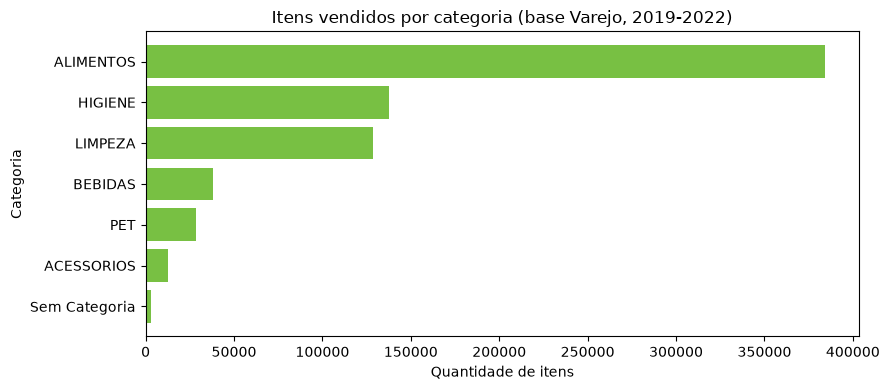

In [14]:
import matplotlib.pyplot as plt
import pandas as pd


def tratar_categoria(valor):
    if valor == "#N/D" or valor == "":
        return "Sem Categoria"
    else:
        return valor


def tratar_nome_produto(valor):
    if valor == "#N/D" or valor == "":
        return "Produto não identificado"
    else:
        return valor


df = pd.read_csv("dataset/varejo.csv", sep=";")
df = df.dropna(axis=1, how="all")                              # Passo 4
df["PR_CAT"] = df["PR_CAT"].apply(tratar_categoria)            # Passo 5
df["PR_NOME"] = df["PR_NOME"].apply(tratar_nome_produto)       # Passo 5
df = df.drop_duplicates()                                      # Passo 6

por_categoria = df.groupby("PR_CAT")["PR_ID"].count().sort_values(ascending=False)
tabela = pd.DataFrame({
    "itens": por_categoria,
    "percentual": (por_categoria / por_categoria.sum() * 100).round(1),
})
display(tabela)

plt.figure(figsize=(9, 4))
plt.barh(tabela.index, tabela["itens"], color="#78C043")
plt.gca().invert_yaxis()
plt.title("Itens vendidos por categoria (base Varejo, 2019-2022)")
plt.xlabel("Quantidade de itens")
plt.ylabel("Categoria")
plt.tight_layout()
plt.show()

**Leitura:** **ALIMENTOS** domina com mais da metade dos itens, seguido de **HIGIENE** e **LIMPEZA**. A categoria **Sem Categoria**, criada no Passo 5, aparece na lista com uma fatia pequena: ela continua visível, em vez de sumir da análise.

## Passo 12 — Agrupamento 3: ano (como as vendas variam no tempo?)

### 📖 Antes do código

Com a data convertida (Passo 7), a coluna `ANO` permite agrupar as compras por ano. É o mesmo `groupby()`, agora com `nunique()` do `CO_ID` para contar compras, `count()` para contar itens e `nunique()` da `DATA` para contar em quantos dias diferentes houve venda.

In [15]:
from datetime import datetime

import pandas as pd


def converter_data(texto):
    try:
        return datetime.strptime(texto, "%d/%m/%Y")
    except ValueError:
        return None


df = pd.read_csv("dataset/varejo.csv", sep=";")
df = df.dropna(axis=1, how="all")                              # Passo 4
df = df.drop_duplicates()                                      # Passo 6
df["DATA"] = pd.to_datetime(df["DATA"].apply(converter_data))  # Passo 7
df["ANO"] = df["DATA"].dt.year                                 # Passo 7

por_ano = pd.DataFrame({
    "compras": df.groupby("ANO")["CO_ID"].nunique(),
    "itens": df.groupby("ANO")["PR_ID"].count(),
    "dias_com_venda": df.groupby("ANO")["DATA"].nunique(),
})
por_ano["compras_por_dia"] = (por_ano["compras"] / por_ano["dias_com_venda"]).round(1)
display(por_ano)

,compras,itens,dias_com_venda,compras_por_dia
ANO,,,,
2019,4483,176103,88,50.9
2020,4794,192804,89,53.9
2021,5505,216813,97,56.8
2022,3689,147727,59,62.5


**Leitura:** olhe a coluna `dias_com_venda`. A base **não tem todos os dias do ano**: são 333 datas em quase 4 anos. Por isso, uma diferença de compras entre anos pode vir de **quantos dias foram registrados**, e não de o varejo ter vendido mais ou menos. A coluna `compras_por_dia` compara os anos de forma justa. Esse é um "problema remanescente" que vai para as conclusões.

## Passo 13 — Salvando a base limpa (`df_limpo.csv`)

### 📖 Antes do código

O enunciado pede o arquivo `df_limpo.csv` junto com o projeto. A célula aplica **todas** as limpezas, na ordem, e grava o resultado com `to_csv()`:

| Parâmetro | O que faz |
|---|---|
| `"df_limpo.csv"` | nome do arquivo (é criado nesta mesma pasta) |
| `index=False` | não grava a numeração de linhas do Pandas como uma coluna a mais |
| `sep=";"` | mantém o ponto e vírgula, igual à base original |

Depois de gravar, a célula **abre o arquivo de novo** com `pd.read_csv()`: é a prova de que o arquivo existe e está correto.

In [16]:
from datetime import datetime

import pandas as pd


def tratar_categoria(valor):
    if valor == "#N/D" or valor == "":
        return "Sem Categoria"
    else:
        return valor


def tratar_nome_produto(valor):
    if valor == "#N/D" or valor == "":
        return "Produto não identificado"
    else:
        return valor


def converter_data(texto):
    try:
        return datetime.strptime(texto, "%d/%m/%Y")
    except ValueError:
        return None


df = pd.read_csv("dataset/varejo.csv", sep=";")
df = df.dropna(axis=1, how="all")                              # Passo 4: nulos
df["PR_CAT"] = df["PR_CAT"].apply(tratar_categoria)            # Passo 5: categorias vazias
df["PR_NOME"] = df["PR_NOME"].apply(tratar_nome_produto)       # Passo 5
df = df.drop_duplicates()                                      # Passo 6: duplicatas
df["DATA"] = pd.to_datetime(df["DATA"].apply(converter_data))  # Passo 7: datas
df["ANO"] = df["DATA"].dt.year                                 # Passo 7

df.to_csv("df_limpo.csv", index=False, sep=";")
print("Arquivo df_limpo.csv gravado.")

conferencia = pd.read_csv("df_limpo.csv", sep=";")
print("Formato do arquivo reaberto (linhas, colunas):", conferencia.shape)
print("Nulos no arquivo:", conferencia.isna().sum().sum())
print("Duplicatas no arquivo:", conferencia.duplicated().sum())
print("'#N/D' no arquivo:", (conferencia["PR_CAT"] == "#N/D").sum())
display(conferencia.head())

Arquivo df_limpo.csv gravado.
Formato do arquivo reaberto (linhas, colunas): (733447, 11)
Nulos no arquivo: 0
Duplicatas no arquivo: 0
'#N/D' no arquivo: 0


,DATA,CO_ID,CL_ID,CL_GENERO,CL_EC,CL_FHL,CL_SEG,PR_ID,PR_CAT,PR_NOME,ANO
0,2019-02-01,1000,534,M,4,1,C,67,BEBIDAS,REFRIGERANTE GUARANA,2019
1,2019-02-01,1000,534,M,4,1,C,70,BEBIDAS,REFRIGERANTE OUTROS,2019
2,2019-02-01,1000,534,M,4,1,C,178,HIGIENE,LENCO UMEDECIDO,2019
3,2019-02-01,1000,534,M,4,1,C,4,ALIMENTOS,ABACAXI,2019
4,2019-02-01,1000,534,M,4,1,C,175,LIMPEZA,LIMPADOR MULTIUSO,2019


O arquivo reaberto tem **733.447 linhas e 11 colunas** (as 10 originais + `ANO`), com **zero** nulos, **zero** duplicatas e **zero** `#N/D`. A data foi gravada no formato `2019-02-01` (ano-mês-dia), o padrão usado por bancos de dados e pelo Power BI.

O `df_limpo.csv` é **resultado** do seu notebook: ele é criado quando você executa, por isso não vem pronto no repositório.

## Passo 14 — Relatório final e conclusões (Sprint 5)

### 📖 Antes do código

O relatório final **não tem nenhum número digitado à mão**: a célula refaz as contas a partir do `df_limpo.csv` (gerado no Passo 13) e monta cada frase com uma **f-string** (o `f"..."` que coloca o valor de uma variável dentro do texto, entre chaves). Se a base mudar, as conclusões mudam junto.

A função `milhar()` coloca o separador de milhar no padrão brasileiro: o formato `{numero:,}` usa a vírgula, e o `.replace(",", ".")` troca por ponto. A função `decimal()` faz o mesmo com a casa decimal: o formato `{numero:.1f}` mostra 1 casa depois do ponto, e o `.replace(".", ",")` troca o ponto pela vírgula. O `idxmax()` devolve o **nome** da linha com o maior valor (aqui, o gênero com mais compras). A conclusão 2 usa um `if/else`: o texto muda conforme a diferença entre os gêneros seja pequena ou grande.

In [17]:
import pandas as pd

df = pd.read_csv("df_limpo.csv", sep=";")


def milhar(numero):
    return f"{numero:,}".replace(",", ".")


linhas_originais = 830000
compras = df["CO_ID"].nunique()
clientes = df.drop_duplicates(subset="CL_ID")
filhos = clientes["CL_FHL"]
sem_filhos = (filhos == 0).sum() / len(filhos) * 100

categorias = df.groupby("PR_CAT")["PR_ID"].count().sort_values(ascending=False)
categoria_lider = categorias.index[0]
percentual_lider = categorias.iloc[0] / categorias.sum() * 100
sem_categoria = int(categorias["Sem Categoria"])

genero = pd.DataFrame({
    "compras": df.groupby("CL_GENERO")["CO_ID"].nunique(),
    "clientes": df.groupby("CL_GENERO")["CL_ID"].nunique(),
})
genero["compras_por_cliente"] = genero["compras"] / genero["clientes"]
genero_mais_compras = genero["compras"].idxmax()

por_ano = pd.DataFrame({
    "compras": df.groupby("ANO")["CO_ID"].nunique(),
    "dias": df.groupby("ANO")["DATA"].nunique(),
})
por_ano["compras_por_dia"] = por_ano["compras"] / por_ano["dias"]
primeiro_ano = por_ano.index[0]
ultimo_ano = por_ano.index[-1]


def decimal(numero, casas=1):
    return f"{numero:.{casas}f}".replace(".", ",")


print("=" * 70)
print("RELATÓRIO FINAL — Análise Exploratória da base Varejo")
print("=" * 70)
print(f"Registros na base original:  {milhar(linhas_originais)}")
print(f"Registros na base limpa:     {milhar(len(df))}")
print(f"Duplicatas removidas:        {milhar(linhas_originais - len(df))}")
print(f"Compras (CO_ID diferentes):  {milhar(compras)}")
print(f"Clientes diferentes:         {milhar(len(clientes))}")
print(f"Itens 'Sem Categoria':       {milhar(sem_categoria)}")
print()
print("CONCLUSÕES")
print(f"1. {categoria_lider} é a categoria mais vendida, com {decimal(percentual_lider)}% dos itens: "
      f"é o carro-chefe do varejo e deve ter prioridade em estoque e promoções.")

g1 = genero.index[0]
g2 = genero.index[1]
diferenca = abs(genero.loc[g1, "compras_por_cliente"] - genero.loc[g2, "compras_por_cliente"])
if diferenca < 1:
    print(f"2. O gênero {genero_mais_compras} fez mais compras no total, mas também tem mais clientes. "
          f"Por cliente, a frequência é quase igual ({g1} = {decimal(genero.loc[g1, 'compras_por_cliente'])} e "
          f"{g2} = {decimal(genero.loc[g2, 'compras_por_cliente'])} compras): a diferença vem do número de clientes.")
else:
    print(f"2. O gênero {genero_mais_compras} fez mais compras no total, e a diferença por cliente é de "
          f"{decimal(diferenca)} compras: cada cliente desse gênero compra mais vezes.")

print(f"3. O cliente típico não tem filhos: {decimal(sem_filhos)}% dos clientes têm 0 filho (mediana {filhos.median():.0f}, "
      f"moda {filhos.mode()[0]}); a média de {decimal(filhos.mean(), 2)} fica acima porque poucos clientes têm 3 ou 4 filhos.")
print(f"4. O movimento por dia cresceu: de {decimal(por_ano.loc[primeiro_ano, 'compras_por_dia'])} compras por dia em {primeiro_ano} "
      f"para {decimal(por_ano.loc[ultimo_ano, 'compras_por_dia'])} em {ultimo_ano}. Comparar totais por ano engana, "
      f"porque cada ano tem uma quantidade diferente de dias registrados.")
print(f"5. Cada CO_ID é uma compra com 1 cliente e 1 data (regra validada). Uma compra tem em média "
      f"{decimal(len(df) / compras)} itens: contar linhas é contar itens, e não compras.")
print(f"6. Problemas remanescentes: não há coluna de quantidade nem de valor (as duplicatas removidas podem ser "
      f"2 unidades do mesmo produto), as datas não cobrem todos os dias do ano, e {milhar(sem_categoria)} itens "
      f"continuam 'Sem Categoria' até o cadastro de produtos ser corrigido na origem.")

RELATÓRIO FINAL — Análise Exploratória da base Varejo
Registros na base original:  830.000
Registros na base limpa:     733.447
Duplicatas removidas:        96.553
Compras (CO_ID diferentes):  18.471
Clientes diferentes:         1.000
Itens 'Sem Categoria':       3.228

CONCLUSÕES
1. ALIMENTOS é a categoria mais vendida, com 52,4% dos itens: é o carro-chefe do varejo e deve ter prioridade em estoque e promoções.
2. O gênero F fez mais compras no total, mas também tem mais clientes. Por cliente, a frequência é quase igual (F = 18,5 e M = 18,4 compras): a diferença vem do número de clientes.
3. O cliente típico não tem filhos: 52,7% dos clientes têm 0 filho (mediana 0, moda 0); a média de 1,14 fica acima porque poucos clientes têm 3 ou 4 filhos.
4. O movimento por dia cresceu: de 50,9 compras por dia em 2019 para 62,5 em 2022. Comparar totais por ano engana, porque cada ano tem uma quantidade diferente de dias registrados.
5. Cada CO_ID é uma compra com 1 cliente e 1 data (regra validada

Estas são as **conclusões do projeto** (3 a 6 tópicos, como pede o enunciado). No projeto entregue no GitHub, elas também vão para o `README.md`.

### ✅ Você chegou ao fim

Você executou uma Análise Exploratória completa: leu a base de dois jeitos (`csv.DictReader` e Pandas), encontrou três problemas (colunas vazias, duplicatas e `#N/D`), limpou cada um com uma decisão justificada, converteu a data com `datetime`, validou a regra da compra, calculou as estatísticas do número de filhos, fez três agrupamentos, gravou o `df_limpo.csv` e escreveu as conclusões a partir dos números.

---
*Prof. Especialista Cláudio F. Neves*